# Federated Learning trên dữ liệu Non-IID — CIFAR-10

Notebook này thực nghiệm **5 thuật toán tổng hợp trọng số** (FedAvg, FedProx, FedNova, SCAFFOLD, MOON)
trên **5 kiểu phân phối dữ liệu non-IID** khác nhau (IID, Label Skew, Feature Skew, Quantity Skew,
Concept Shift), dùng tập dữ liệu **CIFAR-10**.

**Cách dùng:**
1. Vào `Runtime > Change runtime type` → chọn **T4 GPU**.
2. Chạy tuần tự từ trên xuống. Mục **CONFIG** ở Cell 3 là nơi chỉnh mọi tham số.
3. Mục "Chạy thử nhanh 1 cấu hình" giúp kiểm tra mọi thứ hoạt động trước khi chạy toàn bộ lưới thực nghiệm (25 tổ hợp) ở cuối notebook.
4. Kết quả được lưu ra file JSON sau mỗi tổ hợp — nếu Colab bị ngắt kết nối, chạy lại cell grid sẽ **tự động bỏ qua** các tổ hợp đã xong.

**Cấu hình mặc định** được chọn để chạy vừa phải trên GPU T4 miễn phí (~40-60 phút cho toàn bộ 25 tổ hợp).
Muốn kết quả chính xác/đáng tin hơn, tăng `train_subset_size`, `num_rounds`, `num_clients` trong CONFIG (sẽ chạy lâu hơn).


In [14]:
# ================= CÀI ĐẶT & IMPORT =================
import os, sys, copy, time, math, random, json, itertools
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from datasets import load_dataset

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang chạy trên thiết bị: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  Không tìm thấy GPU. Vào Runtime > Change runtime type > chọn T4 GPU để tăng tốc đáng kể.")


Đang chạy trên thiết bị: cpu
⚠️  Không tìm thấy GPU. Vào Runtime > Change runtime type > chọn T4 GPU để tăng tốc đáng kể.


In [15]:
# ============================================================
# CẤU HÌNH THỰC NGHIỆM — chia thành algorithm config, data config, và base config
# ============================================================

# ---- BASE CONFIG: Cài đặt chung cho tất cả thực nghiệm ----
BASE_CONFIG = {
    "num_clients": 10,
    "client_fraction": 1.0,
    "seed": 42,
    "eval_every": 1,
    "num_workers": 2,
}

# ---- ALGORITHM CONFIGS: Cấu hình riêng cho từng thuật toán ----
ALGORITHM_CONFIGS = {
    "fedavg": {
        "num_rounds": 15,
        "local_epochs": 3,
        "batch_size": 64,
        "lr": 0.01,
        "momentum": 0.9,
        "weight_decay": 1e-5,
        # FedAvg không có tham số riêng
    },
    "fedprox": {
        "num_rounds": 15,
        "local_epochs": 3,
        "batch_size": 64,
        "lr": 0.01,
        "momentum": 0.9,
        "weight_decay": 1e-5,
        "fedprox_mu": 0.01,  # hệ số phạt proximal term — điều chỉnh để ổn định hơn với dữ liệu lệch
    },
    "fednova": {
        "num_rounds": 15,
        "local_epochs": 3,
        "batch_size": 64,
        "lr": 0.01,
        "momentum": 0.9,
        "weight_decay": 1e-5,
        # FedNova dùng chuẩn hoá step count, không có tham số riêng
    },
    "scaffold": {
        "num_rounds": 15,
        "local_epochs": 3,
        "batch_size": 64,
        "lr": 0.01,
        "momentum": 0.0,  # SCAFFOLD dùng vanilla SGD không momentum
        "weight_decay": 1e-5,
        "scaffold_server_lr": 1.0,  # learning rate phía server
    },
    "moon": {
        "num_rounds": 15,
        "local_epochs": 3,
        "batch_size": 64,
        "lr": 0.01,
        "momentum": 0.9,
        "weight_decay": 1e-5,
        "moon_mu": 1.0,  # trọng số loss contrastive
        "moon_temperature": 0.5,  # temperature cho cosine similarity
    },
}

# ---- DATA PARTITION CONFIGS: Cấu hình riêng cho từng kiểu phân phối dữ liệu ----
DATA_PARTITION_CONFIGS = {
    "iid": {
        "train_subset_size": 10000,
        "test_subset_size": 2000,
        # IID không có tham số phân phối
    },
    "label_skew": {
        "train_subset_size": 10000,
        "test_subset_size": 2000,
        "label_skew_alpha": 0.5,  # Dirichlet alpha: nhỏ = lệch mạnh, lớn = gần IID
    },
    "quantity_skew": {
        "train_subset_size": 10000,
        "test_subset_size": 2000,
        "quantity_skew_alpha": 0.5,  # Dirichlet alpha trên số lượng mẫu/client
    },
    "feature_skew": {
        "train_subset_size": 10000,
        "test_subset_size": 2000,
        "feature_skew_groups": 4,  # 4 nhóm biến đổi ảnh khác nhau (normal, colorjitter, blur, grayscale)
    },
    "concept_shift": {
        "train_subset_size": 10000,
        "test_subset_size": 2000,
        "concept_shift_groups": 2,  # 2 nhóm ánh xạ nhãn khác nhau (gốc, hoán đổi)
    },
}

# ---- TÀI SẢN CHUỖI: Nhãn hiển thị cho người dùng ----
PARTITION_LABELS_VI = {
    "iid": "IID (đồng nhất)",
    "label_skew": "Label Skew (lệch nhãn)",
    "feature_skew": "Feature Skew (lệch đặc trưng)",
    "quantity_skew": "Quantity Skew (lệch số lượng)",
    "concept_shift": "Concept Shift (lệch khái niệm)",
}

# ---- HÀM HỢP NHẤT CONFIG: Tự động chọn config dựa vào thuật toán + kiểu dữ liệu ----
def get_config(algorithm, partition):
    """
    Hợp nhất BASE_CONFIG + ALGORITHM_CONFIG + DATA_PARTITION_CONFIG.
    Ưu tiên: BASE_CONFIG < ALGORITHM_CONFIG < DATA_PARTITION_CONFIG
    """
    if algorithm not in ALGORITHM_CONFIGS:
        raise ValueError(f"❌ Thuật toán '{algorithm}' không được hỗ trợ. Chọn từ: {list(ALGORITHM_CONFIGS.keys())}")
    if partition not in DATA_PARTITION_CONFIGS:
        raise ValueError(f"❌ Kiểu phân phối '{partition}' không được hỗ trợ. Chọn từ: {list(DATA_PARTITION_CONFIGS.keys())}")

    config = dict(BASE_CONFIG)
    config.update(ALGORITHM_CONFIGS[algorithm])
    config.update(DATA_PARTITION_CONFIGS[partition])
    config["algorithm"] = algorithm
    config["partition"] = partition
    config["data_root"] = "./data"
    return config

# ---- CHỌN THUẬT TOÁN VÀ KIỂU DỮ LIỆU CẦN CHẠY ----
SELECTED_ALGORITHM = "fedavg"      # Thay đổi thành: "fedavg", "fedprox", "fednova", "scaffold", "moon"
SELECTED_PARTITION = "label_skew"  # Thay đổi thành: "iid", "label_skew", "quantity_skew", "feature_skew", "concept_shift"

# ---- TẠO CONFIG HIỆN TẠI ----
CONFIG = get_config(SELECTED_ALGORITHM, SELECTED_PARTITION)

# ---- DANH SÁCH THỰC NGHIỆM TOÀN BỘ LƯỚI ----
EXPERIMENT_ALGORITHMS = ["fedavg", "fedprox", "fednova", "scaffold", "moon"]
EXPERIMENT_PARTITIONS = ["iid", "label_skew", "feature_skew", "quantity_skew", "concept_shift"]

RESULTS_FILE_TEMPLATE = "fl_experiment_results_{algorithm}.json"


def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
print(f"✅ Thuật toán: {SELECTED_ALGORITHM.upper()}")
print(f"✅ Kiểu dữ liệu: {PARTITION_LABELS_VI.get(SELECTED_PARTITION)}")
print("\n📋 Cấu hình hiện tại:")
for k, v in sorted(CONFIG.items()):
    print(f"  {k}: {v}")


✅ Thuật toán: FEDAVG
✅ Kiểu dữ liệu: Label Skew (lệch nhãn)

📋 Cấu hình hiện tại:
  algorithm: fedavg
  batch_size: 64
  client_fraction: 1.0
  data_root: ./data
  eval_every: 1
  label_skew_alpha: 0.5
  local_epochs: 3
  lr: 0.01
  momentum: 0.9
  num_clients: 10
  num_rounds: 15
  num_workers: 2
  partition: label_skew
  seed: 42
  test_subset_size: 2000
  train_subset_size: 10000
  weight_decay: 1e-05


Đang tải CIFAR-10 (chỉ tải lần đầu, các lần sau dùng cache) ...
Train: 10000 ảnh | Test: 2000 ảnh


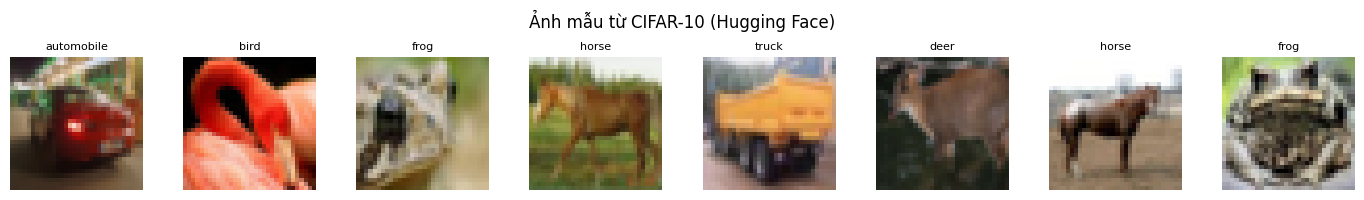

In [16]:
from datasets import load_dataset
# ================= TẢI DỮ LIỆU CIFAR-10 =================
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)
CLASS_NAMES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

print("Đang tải CIFAR-10 (chỉ tải lần đầu, các lần sau dùng cache) ...")
dataset = load_dataset("uoft-cs/cifar10")


def subset_hf_dataset(ds, n, seed):
    """Lấy ngẫu nhiên n mẫu từ Hugging Face Dataset."""
    if n is None or n >= len(ds):
        return ds
    return ds.shuffle(seed=seed).select(range(n))


def hf_dataset_to_compat(ds):
    """Bọc Hugging Face Dataset thành format tương thích với các cell phía sau.

    Đối tượng trả về có:
    - .data: numpy array HxWxC
    - .targets: list nhãn
    - __getitem__ trả về {'img': PIL.Image, 'label': int}
    """
    class CompatDataset:
        def __init__(self, hf_ds):
            self.data = np.stack([np.array(sample['img']) for sample in hf_ds])
            self.targets = [int(sample['label']) for sample in hf_ds]

        def __len__(self):
            return len(self.targets)

        def __getitem__(self, idx):
            return {
                'img': Image.fromarray(self.data[idx]),
                'label': self.targets[idx],
            }

    return CompatDataset(ds)


# Phân chia và lấy subset
train_base = hf_dataset_to_compat(subset_hf_dataset(dataset["train"], CONFIG["train_subset_size"], CONFIG["seed"]))
test_base  = hf_dataset_to_compat(subset_hf_dataset(dataset["test"],  CONFIG["test_subset_size"],  CONFIG["seed"] + 1))

print(f"Train: {len(train_base)} ảnh | Test: {len(test_base)} ảnh")

# Xem thử vài ảnh mẫu
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    sample = train_base[i]
    img = sample['img']
    label = sample['label']

    ax.imshow(img)
    ax.set_title(CLASS_NAMES[label], fontsize=8)
    ax.axis('off')

plt.suptitle("Ảnh mẫu từ CIFAR-10 (Hugging Face)")
plt.tight_layout()
plt.show()


## Các phép chia dữ liệu Non-IID

Mỗi hàm dưới đây trả về danh sách chỉ số (indices) dữ liệu train cho từng client, mô phỏng một dạng
lệch dữ liệu (non-IID) thường gặp trong thực tế:

| Kiểu | Mô tả | Cách mô phỏng |
|---|---|---|
| **IID** | Dữ liệu chia ngẫu nhiên, đồng nhất | Random split đều |
| **Label Skew** | Mỗi client có tỉ lệ lớp (class) khác nhau | Phân phối Dirichlet(alpha) trên từng lớp |
| **Quantity Skew** | Mỗi client có SỐ LƯỢNG mẫu khác nhau (nhưng tỉ lệ lớp ~giống nhau) | Phân phối Dirichlet(alpha) trên tổng số mẫu |
| **Feature Skew** | Cùng nhãn nhưng đặc trưng ảnh khác nhau (khác "domain") | Chia client thành nhóm, mỗi nhóm áp dụng 1 phép biến đổi ảnh khác nhau (màu sắc, độ mờ, grayscale...) |
| **Concept Shift** | Cùng ảnh X nhưng ánh xạ nhãn Y khác nhau giữa các nhóm client, tức P(Y\|X) thay đổi | Chia client thành nhóm, 1 nhóm hoán đổi nhãn giữa các cặp lớp (vd: cat↔dog) |


In [17]:
# ================= CÁC HÀM PHÂN PHỐI (PARTITION) DỮ LIỆU =================

def partition_iid(labels, num_clients, rng):
    """Chia đều, ngẫu nhiên — mỗi client có phân phối lớp và số lượng mẫu tương tự nhau."""
    idxs = rng.permutation(len(labels))
    return [arr.tolist() for arr in np.array_split(idxs, num_clients)]


def partition_label_skew(labels, num_clients, alpha, rng, min_size_thresh=10):
    """Label skew theo Dirichlet — chuẩn phổ biến trong các benchmark Non-IID FL (Li et al., 2022).
    alpha càng nhỏ thì mỗi client càng tập trung vào một vài lớp nhất định."""
    labels = np.array(labels)
    num_classes = len(np.unique(labels))
    N = len(labels)
    min_size = 0
    idx_batch = None
    tries = 0
    while min_size < min_size_thresh and tries < 50:
        tries += 1
        idx_batch = [[] for _ in range(num_clients)]
        for k in range(num_classes):
            idx_k = np.where(labels == k)[0]
            rng.shuffle(idx_k)
            proportions = rng.dirichlet(np.repeat(alpha, num_clients))
            # tránh dồn quá nhiều vào 1 client đã đủ dữ liệu
            proportions = np.array([p * (len(idx_j) < N / num_clients) for p, idx_j in zip(proportions, idx_batch)])
            proportions = proportions / proportions.sum() if proportions.sum() > 0 else np.ones(num_clients) / num_clients
            splits = (np.cumsum(proportions) * len(idx_k)).astype(int)[:-1]
            for j, part in enumerate(np.split(idx_k, splits)):
                idx_batch[j].extend(part.tolist())
        min_size = min(len(x) for x in idx_batch)
    return idx_batch


def partition_quantity_skew(labels, num_clients, alpha, rng, min_size=50, max_tries=100):
    """Quantity skew theo Dirichlet — phân phối lớp giữ nguyên (xấp xỉ IID) nhưng SỐ LƯỢNG
    mẫu mỗi client chênh lệch rất khác nhau."""
    N = len(labels)
    idxs = rng.permutation(N)
    sizes, cand = None, None
    for _ in range(max_tries):
        proportions = rng.dirichlet(np.repeat(alpha, num_clients))
        cand = (proportions * N).astype(int)
        if cand.min() >= min_size:
            sizes = cand
            break
    if sizes is None:  # fallback: đảm bảo sàn tối thiểu nếu quá nhiều lần thử vẫn không đạt
        cand = np.maximum(cand, min_size)
        cand = (cand / cand.sum() * N).astype(int)
        sizes = cand
    sizes[-1] = N - sizes[:-1].sum()
    splits = np.cumsum(sizes)[:-1]
    return [arr.tolist() for arr in np.split(idxs, splits)]


def partition_group_iid(labels, num_clients, num_groups, rng):
    """Chia dữ liệu IID như bình thường, nhưng gán mỗi client vào 1 trong num_groups nhóm.
    Dùng làm nền cho feature_skew (nhóm quyết định phép biến đổi ảnh) và
    concept_shift (nhóm quyết định ánh xạ nhãn)."""
    idxs = partition_iid(labels, num_clients, rng)
    groups = [i % num_groups for i in range(num_clients)]
    return idxs, groups


In [18]:
# ================= TRANSFORM CHO FEATURE SKEW & LABEL MAP CHO CONCEPT SHIFT =================
DEFAULT_TRANSFORM = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Feature skew: mỗi nhóm client "nhìn" ảnh qua 1 phép biến đổi khác nhau -> khác phân phối đặc trưng
# (mô phỏng khác camera / ánh sáng / cảm biến giữa các client, giống tinh thần benchmark CIFAR-10-C)
FEATURE_SKEW_TRANSFORMS = [
    T.Compose([T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)]),                       # nhóm 0: ảnh gốc
    T.Compose([T.ColorJitter(brightness=0.7, contrast=0.7, saturation=0.7, hue=0.2),
               T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)]),                        # nhóm 1: khác màu/ánh sáng
    T.Compose([T.GaussianBlur(kernel_size=3, sigma=(0.5, 2.0)),
               T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)]),                        # nhóm 2: khác độ nét (mờ)
    T.Compose([T.Grayscale(num_output_channels=3),
               T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)]),                        # nhóm 3: khác loại cảm biến (grayscale)
]

# Concept shift: cùng ảnh X nhưng nhãn Y bị hoán đổi theo nhóm -> P(Y|X) khác nhau giữa các client
CONCEPT_SHIFT_LABEL_MAPS = [
    None,                                    # nhóm 0: ánh xạ gốc, không đổi
    {1: 9, 9: 1, 3: 5, 5: 3, 4: 7, 7: 4},     # nhóm 1: hoán đổi automobile<->truck, cat<->dog, deer<->horse
]


class ClientDataset(Dataset):
    """Dataset của 1 client: 1 tập chỉ số con của dataset gốc + transform + (tuỳ chọn) ánh xạ nhãn riêng."""
    def __init__(self, base, indices, transform, label_map=None):
        self.base = base
        self.indices = indices
        self.transform = transform
        self.label_map = label_map

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        real_i = self.indices[i]
        img = Image.fromarray(self.base.data[real_i])
        label = int(self.base.targets[real_i])
        if self.label_map is not None:
            label = self.label_map.get(label, label)
        return self.transform(img), label


def build_client_partition(partition_type, base_dataset, cfg):
    """Điểm vào duy nhất: trả về (indices, transforms, label_maps, groups) cho 1 kiểu non-IID."""
    labels = base_dataset.targets
    num_clients = cfg["num_clients"]
    rng = np.random.RandomState(cfg["seed"])

    if partition_type == "iid":
        idxs = partition_iid(labels, num_clients, rng)
        transforms_list = [DEFAULT_TRANSFORM] * num_clients
        label_maps = [None] * num_clients
        groups = [0] * num_clients
    elif partition_type == "label_skew":
        idxs = partition_label_skew(labels, num_clients, cfg["label_skew_alpha"], rng)
        transforms_list = [DEFAULT_TRANSFORM] * num_clients
        label_maps = [None] * num_clients
        groups = [0] * num_clients
    elif partition_type == "quantity_skew":
        idxs = partition_quantity_skew(labels, num_clients, cfg["quantity_skew_alpha"], rng)
        transforms_list = [DEFAULT_TRANSFORM] * num_clients
        label_maps = [None] * num_clients
        groups = [0] * num_clients
    elif partition_type == "feature_skew":
        idxs, groups = partition_group_iid(labels, num_clients, cfg["feature_skew_groups"], rng)
        transforms_list = [FEATURE_SKEW_TRANSFORMS[g % len(FEATURE_SKEW_TRANSFORMS)] for g in groups]
        label_maps = [None] * num_clients
    elif partition_type == "concept_shift":
        idxs, groups = partition_group_iid(labels, num_clients, cfg["concept_shift_groups"], rng)
        transforms_list = [DEFAULT_TRANSFORM] * num_clients
        label_maps = [CONCEPT_SHIFT_LABEL_MAPS[g % len(CONCEPT_SHIFT_LABEL_MAPS)] for g in groups]
    else:
        raise ValueError(f"Không hỗ trợ partition: {partition_type}")

    return idxs, transforms_list, label_maps, groups


def make_client_loaders(base_dataset, idxs, transforms_list, label_maps, cfg, shuffle=True):
    loaders = []
    for i in range(len(idxs)):
        ds = ClientDataset(base_dataset, idxs[i], transforms_list[i], label_maps[i])
        loaders.append(DataLoader(
            ds, batch_size=cfg["batch_size"], shuffle=shuffle,
            num_workers=cfg["num_workers"] if DEVICE.type == "cuda" else 0,
            drop_last=False,
        ))
    return loaders


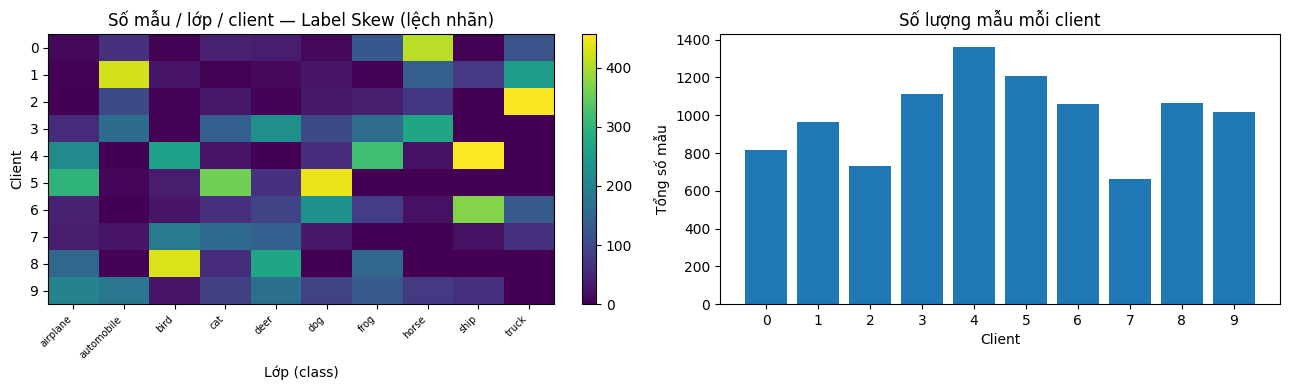

Tổng số mẫu: 10000 | Client nhỏ nhất: 663 | Client lớn nhất: 1360


In [19]:
# ================= TRỰC QUAN HOÁ PHÂN PHỐI DỮ LIỆU CLIENT =================
def plot_partition_summary(idxs, labels, groups, partition_type, num_classes=10):
    labels = np.array(labels)
    num_clients = len(idxs)
    mat = np.zeros((num_clients, num_classes), dtype=int)
    for c, id_list in enumerate(idxs):
        for cls in labels[id_list]:
            mat[c, cls] += 1

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    im = axes[0].imshow(mat, aspect="auto", cmap="viridis")
    axes[0].set_xlabel("Lớp (class)"); axes[0].set_ylabel("Client")
    axes[0].set_title(f"Số mẫu / lớp / client — {PARTITION_LABELS_VI.get(partition_type, partition_type)}")
    axes[0].set_xticks(range(num_classes)); axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=7)
    axes[0].set_yticks(range(num_clients))
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    sizes = mat.sum(axis=1)
    axes[1].bar(range(num_clients), sizes, color=plt.cm.tab10(np.array(groups) % 10))
    axes[1].set_xlabel("Client"); axes[1].set_ylabel("Tổng số mẫu")
    title = "Số lượng mẫu mỗi client"
    if len(set(groups)) > 1:
        title += " (màu = nhóm biến đổi/ánh xạ nhãn)"
    axes[1].set_title(title)
    axes[1].set_xticks(range(num_clients))
    plt.tight_layout()
    plt.show()

    print(f"Tổng số mẫu: {sizes.sum()} | Client nhỏ nhất: {sizes.min()} | Client lớn nhất: {sizes.max()}")


# Minh hoạ với kiểu partition đang chọn trong CONFIG
idxs_demo, tfs_demo, lmaps_demo, groups_demo = build_client_partition(CONFIG["partition"], train_base, CONFIG)
plot_partition_summary(idxs_demo, train_base.targets, groups_demo, CONFIG["partition"])


## Mô hình

CNN nhỏ, dùng **GroupNorm** thay vì BatchNorm (BatchNorm ước lượng thống kê theo batch — với dữ liệu
non-IID và batch nhỏ ở từng client, thống kê này rất nhiễu và làm chậm hội tụ; GroupNorm chuẩn hoá theo
từng mẫu nên ổn định hơn nhiều trong Federated Learning).

Model trả về cả **logits** (để tính CrossEntropy) và **feature vector z** (để tính contrastive loss cho MOON).


In [20]:
# ================= MÔ HÌNH =================
def group_norm(channels, groups=8):
    return nn.GroupNorm(min(groups, channels), channels)


class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, proj_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), group_norm(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), group_norm(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                                   # 32 -> 16
            nn.Conv2d(32, 64, 3, padding=1), group_norm(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), group_norm(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                                   # 16 -> 8
            nn.Conv2d(64, 128, 3, padding=1), group_norm(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                                   # 8 -> 4
        )
        self.proj = nn.Sequential(nn.Linear(128 * 4 * 4, proj_dim), nn.ReLU(inplace=True))
        self.classifier = nn.Linear(proj_dim, num_classes)

    def forward(self, x, return_features=False):
        h = self.features(x)
        h = torch.flatten(h, 1)
        z = self.proj(h)
        logits = self.classifier(z)
        if return_features:
            return logits, z
        return logits


def build_model():
    return SimpleCNN(num_classes=10)


_tmp = build_model()
n_params = sum(p.numel() for p in _tmp.parameters())
print(f"Số tham số của model: {n_params:,}")
del _tmp


Số tham số của model: 403,626


## Các thuật toán huấn luyện local & tổng hợp (aggregation)

- **FedAvg** (McMahan et al., 2017): huấn luyện local bằng CrossEntropy thông thường, server lấy trung bình
  trọng số theo tỉ lệ số mẫu.
- **FedProx** (Li et al., 2020): giống FedAvg nhưng thêm proximal term `μ/2·‖w - w_global‖²` vào loss local
  để hạn chế client "đi quá xa" mô hình global — giúp ổn định hơn khi dữ liệu lệch mạnh.
- **FedNova** (Wang et al., 2020): chuẩn hoá cập nhật của mỗi client theo số bước cập nhật local (τᵢ) trước
  khi tổng hợp, giải quyết vấn đề "objective inconsistency" khi các client có số bước huấn luyện khác nhau
  (rất hữu ích với Quantity Skew).
- **SCAFFOLD** (Karimireddy et al., 2020): dùng biến điều khiển (control variates) `c`, `cᵢ` để hiệu chỉnh
  hướng gradient local, giảm "client drift" do dữ liệu non-IID.
- **MOON** (Li et al., 2021): thêm model-contrastive loss kéo biểu diễn (feature) của model local lại gần
  model global và đẩy xa model local của chính nó ở vòng trước — giảm lệch biểu diễn giữa các client.


In [21]:
# ================= HUẤN LUYỆN LOCAL CHO TỪNG THUẬT TOÁN =================

def local_train_fedavg(model, loader, cfg):
    model.train()
    opt = torch.optim.SGD(model.parameters(), lr=cfg["lr"], momentum=cfg["momentum"], weight_decay=cfg["weight_decay"])
    steps = 0
    for _ in range(cfg["local_epochs"]):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            opt.step()
            steps += 1
    return steps


def local_train_fedprox(model, global_params, loader, cfg):
    model.train()
    opt = torch.optim.SGD(model.parameters(), lr=cfg["lr"], momentum=cfg["momentum"], weight_decay=cfg["weight_decay"])
    steps = 0
    for _ in range(cfg["local_epochs"]):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = F.cross_entropy(model(x), y)
            prox = sum(((p - g) ** 2).sum() for p, g in zip(model.parameters(), global_params))
            loss = loss + (cfg["fedprox_mu"] / 2) * prox
            loss.backward()
            opt.step()
            steps += 1
    return steps


def local_train_scaffold(model, c_global, c_local, loader, cfg):
    """Dùng SGD thuần (không momentum) để công thức hiệu chỉnh control-variate đúng như bài báo gốc."""
    model.train()
    opt = torch.optim.SGD(model.parameters(), lr=cfg["lr"])
    steps = 0
    for _ in range(cfg["local_epochs"]):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            with torch.no_grad():
                for p, cl, cg in zip(model.parameters(), c_local, c_global):
                    p.grad.add_(cg - cl)   # hiệu chỉnh gradient: g - c_i + c
            opt.step()
            steps += 1
    return steps


def local_train_moon(model, global_model, prev_model, loader, cfg):
    model.train(); global_model.eval(); prev_model.eval()
    opt = torch.optim.SGD(model.parameters(), lr=cfg["lr"], momentum=cfg["momentum"], weight_decay=cfg["weight_decay"])
    steps = 0
    for _ in range(cfg["local_epochs"]):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            logits, z = model(x, return_features=True)
            with torch.no_grad():
                _, z_glob = global_model(x, return_features=True)
                _, z_prev = prev_model(x, return_features=True)
            ce = F.cross_entropy(logits, y)
            sim_pos = F.cosine_similarity(z, z_glob) / cfg["moon_temperature"]   # cặp dương: (local, global)
            sim_neg = F.cosine_similarity(z, z_prev) / cfg["moon_temperature"]   # cặp âm: (local, local vòng trước)
            con_logits = torch.stack([sim_pos, sim_neg], dim=1)
            con_labels = torch.zeros(x.size(0), dtype=torch.long, device=DEVICE)  # nhãn 0 = cặp dương đứng đầu
            con_loss = F.cross_entropy(con_logits, con_labels)
            loss = ce + cfg["moon_mu"] * con_loss
            loss.backward()
            opt.step()
            steps += 1
    return steps


In [22]:
# ================= TỔNG HỢP TRỌNG SỐ (SERVER-SIDE AGGREGATION) =================

def weighted_avg_state_dicts(state_dicts, weights):
    """Dùng cho FedAvg, FedProx, MOON: trung bình có trọng số theo tỉ lệ số mẫu của client."""
    new_state = copy.deepcopy(state_dicts[0])
    for k in new_state:
        new_state[k] = sum(w * sd[k].float() for w, sd in zip(weights, state_dicts))
    return new_state


def fednova_aggregate(global_state, client_states, taus, weights):
    """FedNova: chuẩn hoá delta của mỗi client theo số bước local (tau) trước khi cộng dồn."""
    d = {k: torch.zeros_like(v).float() for k, v in global_state.items()}
    for sd, tau, w in zip(client_states, taus, weights):
        for k in global_state:
            delta = (global_state[k].float() - sd[k].float()) / tau
            d[k] += w * delta
    tau_eff = sum(w * tau for w, tau in zip(weights, taus))
    return {k: global_state[k].float() - tau_eff * d[k] for k in global_state}


def scaffold_aggregate(global_state, delta_ys, weights_uniform_N, server_lr=1.0):
    """SCAFFOLD: cộng trung bình delta_y (y_i - x) của các client đã tham gia, chia đều cho N client."""
    new_state = copy.deepcopy(global_state)
    for k in new_state:
        agg = sum(w * dy[k].float() for w, dy in zip(weights_uniform_N, delta_ys))
        new_state[k] = new_state[k].float() + server_lr * agg
    return new_state


def evaluate(model, loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss_sum += F.cross_entropy(logits, y, reduction="sum").item()
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return correct / total, loss_sum / total


In [23]:
# ================= VÒNG LẶP HUẤN LUYỆN FEDERATED CHÍNH =================

def run_federated_training(algorithm, partition_type, cfg, verbose=True):
    set_seed(cfg["seed"])
    idxs, tfs, lmaps, groups = build_client_partition(partition_type, train_base, cfg)
    loaders = make_client_loaders(train_base, idxs, tfs, lmaps, cfg, shuffle=True)
    test_loader = DataLoader(
        ClientDataset(test_base, list(range(len(test_base.targets))), DEFAULT_TRANSFORM),
        batch_size=256, shuffle=False,
        num_workers=cfg["num_workers"] if DEVICE.type == "cuda" else 0,
    )

    num_clients = cfg["num_clients"]
    global_model = build_model().to(DEVICE)
    local_model = build_model().to(DEVICE)

    c_global = c_locals = None
    prev_states = ref_global_model = ref_prev_model = None
    if algorithm == "scaffold":
        c_global = [torch.zeros_like(p) for p in global_model.parameters()]
        c_locals = [[torch.zeros_like(p) for p in global_model.parameters()] for _ in range(num_clients)]
    elif algorithm == "moon":
        prev_states = [copy.deepcopy(global_model.state_dict()) for _ in range(num_clients)]
        ref_global_model = build_model().to(DEVICE)
        ref_prev_model = build_model().to(DEVICE)
        for p in ref_global_model.parameters(): p.requires_grad_(False)
        for p in ref_prev_model.parameters(): p.requires_grad_(False)

    rng = np.random.RandomState(cfg["seed"] + 999)
    history = []
    t_start = time.time()

    round_range = range(cfg["num_rounds"])
    pbar = tqdm(round_range, desc=f"{algorithm}/{partition_type}") if verbose else round_range

    for rnd in pbar:
        t0 = time.time()
        global_state = global_model.state_dict()
        num_selected = max(1, int(round(cfg["client_fraction"] * num_clients)))
        selected = list(rng.choice(num_clients, num_selected, replace=False))
        selected = [c for c in selected if len(loaders[c]) > 0]  # bỏ qua client rỗng (hiếm khi xảy ra)
        if len(selected) == 0:
            continue
        sizes = [len(idxs[c]) for c in selected]
        weights = [s / sum(sizes) for s in sizes]

        client_states, taus = [], []
        delta_ys, delta_cs = [], []

        for cid in selected:
            local_model.load_state_dict(global_state)
            loader = loaders[cid]

            if algorithm == "fedavg":
                steps = local_train_fedavg(local_model, loader, cfg)
            elif algorithm == "fedprox":
                gparams = [p.clone().detach() for p in local_model.parameters()]
                steps = local_train_fedprox(local_model, gparams, loader, cfg)
            elif algorithm == "fednova":
                steps = local_train_fedavg(local_model, loader, cfg)  # cùng loss với FedAvg, khác ở bước tổng hợp
                taus.append(steps)
            elif algorithm == "scaffold":
                x0 = [p.clone().detach() for p in local_model.parameters()]
                steps = local_train_scaffold(local_model, c_global, c_locals[cid], loader, cfg)
                y_final = [p.clone().detach() for p in local_model.parameters()]
                new_cl, dy, dc = [], {}, []
                for (k, _), x0_p, y_p, cl, cg in zip(global_state.items(), x0, y_final, c_locals[cid], c_global):
                    new_cl_p = cl - cg + (x0_p - y_p) / (steps * cfg["lr"])
                    new_cl.append(new_cl_p)
                    dc.append(new_cl_p - cl)
                    dy[k] = y_p - x0_p
                c_locals[cid] = new_cl
                delta_ys.append(dy)
                delta_cs.append(dc)
            elif algorithm == "moon":
                ref_global_model.load_state_dict(global_state)
                ref_prev_model.load_state_dict(prev_states[cid])
                steps = local_train_moon(local_model, ref_global_model, ref_prev_model, loader, cfg)
                prev_states[cid] = copy.deepcopy(local_model.state_dict())
            else:
                raise ValueError(algorithm)

            if algorithm != "scaffold":
                client_states.append(copy.deepcopy(local_model.state_dict()))

        if algorithm in ("fedavg", "fedprox", "moon"):
            new_state = weighted_avg_state_dicts(client_states, weights)
        elif algorithm == "fednova":
            new_state = fednova_aggregate(global_state, client_states, taus, weights)
        elif algorithm == "scaffold":
            weights_N = [1.0 / num_clients] * len(selected)
            new_state = scaffold_aggregate(global_state, delta_ys, weights_N, cfg["scaffold_server_lr"])
            for i in range(len(c_global)):
                c_global[i] = c_global[i] + sum(dc[i] for dc in delta_cs) / num_clients

        global_model.load_state_dict(new_state)

        if (rnd + 1) % cfg["eval_every"] == 0 or rnd == cfg["num_rounds"] - 1:
            acc, loss = evaluate(global_model, test_loader)
            history.append(dict(round=rnd + 1, test_acc=acc, test_loss=loss, time_sec=time.time() - t0))
            if verbose:
                pbar.set_postfix(acc=f"{acc:.3f}", loss=f"{loss:.3f}")

    total_time = time.time() - t_start
    if verbose:
        print(f"[{algorithm} | {partition_type}] Hoàn tất {cfg['num_rounds']} round trong {total_time:.1f}s "
              f"| Accuracy cuối: {history[-1]['test_acc']*100:.2f}%")
    return global_model, history


## Chạy lưới thực nghiệm — Từng thuật toán, tất cả kiểu dữ liệu

Chạy **1 thuật toán × 5 kiểu phân phối dữ liệu** (5 tổ hợp) mỗi lần. Kết quả của mỗi thuật toán được lưu vào một file riêng theo dạng `fl_experiment_results_<algorithm>.json` và **ghi đè** theo lần chạy mới nhất.

**Quy trình:**
1. Ở cell bên dưới, đặt `ALGORITHM = "fedavg"`
2. Chạy cell → chạy FedAvg trên tất cả 5 kiểu dữ liệu
3. Thay đổi `ALGORITHM = "fedprox"` (ngay trong cell này)
4. Chạy cell lại → chạy FedProx trên tất cả 5 kiểu dữ liệu
5. Lặp lại cho các thuật toán còn lại: `fednova`, `scaffold`, `moon`
6. Kết thúc: mỗi thuật toán có 1 file kết quả riêng, và Cell cuối sẽ tự đọc các file này để vẽ so sánh


In [24]:
# ================= LƯU / ĐỌC KẾT QUẢ (mỗi thuật toán 1 file, ghi đè theo lần chạy mới nhất) =================

def results_file_for(algorithm):
    return f"fl_experiment_results_{algorithm}.json"


def load_results(results_file):
    if os.path.exists(results_file):
        with open(results_file) as f:
            return json.load(f)
    return {}


def save_results(results_file, results):
    with open(results_file, "w") as f:
        json.dump(results, f, indent=2)


def run_experiment_single_algorithm(algorithm, partitions, cfg_base):
    """Chạy 1 thuật toán với tất cả kiểu phân phối dữ liệu (5 tổ hợp).

    Mỗi thuật toán được lưu vào 1 file riêng: fl_experiment_results_<algorithm>.json.
    File này được ghi đè theo lần chạy mới nhất của thuật toán đó.
    """
    if algorithm not in ALGORITHM_CONFIGS:
        raise ValueError(f"❌ Thuật toán '{algorithm}' không được hỗ trợ. Chọn từ: {list(ALGORITHM_CONFIGS.keys())}")

    results_file = results_file_for(algorithm)
    results = {}
    completed = 0

    print(f"\n{'='*70}")
    print(f"🚀 Bắt đầu chạy: {algorithm.upper()} × {len(partitions)} kiểu dữ liệu Non-IID")
    print(f"📁 File kết quả: {results_file}")
    print(f"{'='*70}\n")

    for partition_type in partitions:
        key = f"{partition_type}__{algorithm}"

        # Tạo config cho tổ hợp này
        cfg_run = get_config(algorithm, partition_type)

        # Chạy huấn luyện và ghi đè kết quả của tổ hợp này nếu đã tồn tại
        print(f"⏳ [{algorithm:10s} | {partition_type:15s}] Đang chạy...", end=" ", flush=True)
        _, history = run_federated_training(algorithm, partition_type, cfg_run, verbose=False)
        results[key] = history
        save_results(results_file, results)

        final_acc = history[-1]['test_acc'] * 100
        print(f"✅ Accuracy cuối = {final_acc:.2f}%")
        completed += 1

    print(f"\n{'='*70}")
    print(f"✅ Hoàn tất: {completed} tổ hợp | Đã lưu vào: {results_file}")
    print(f"{'='*70}\n")

    return results


In [25]:
# ================= CHẠY TỪNG THUẬT TOÁN THEO THỨ TỰ =================
# Test fedAVG

ALGORITHM = "fedavg"  # ← Thay đổi thuật toán ở đây

results= run_experiment_single_algorithm(
    ALGORITHM,
    EXPERIMENT_PARTITIONS,
    BASE_CONFIG)

print(results)



🚀 Bắt đầu chạy: FEDAVG × 5 kiểu dữ liệu Non-IID
📁 File kết quả: fl_experiment_results_fedavg.json

⏳ [fedavg     | iid            ] Đang chạy... 

KeyboardInterrupt: 

In [ ]:
# ================= CHẠY TỪNG THUẬT TOÁN THEO THỨ TỰ =================
# Test fedAVG

ALGORITHM = "fedprox"  # ← Thay đổi thuật toán ở đây

results= run_experiment_single_algorithm(
    ALGORITHM,
    EXPERIMENT_PARTITIONS,
    BASE_CONFIG)

print(results)


In [ ]:
# ================= CHẠY TỪNG THUẬT TOÁN THEO THỨ TỰ =================
# Test fedAVG

ALGORITHM = "fednova"  # ← Thay đổi thuật toán ở đây

results= run_experiment_single_algorithm(
    ALGORITHM,
    EXPERIMENT_PARTITIONS,
    BASE_CONFIG)

print(results)


In [ ]:
# ================= CHẠY TỪNG THUẬT TOÁN THEO THỨ TỰ =================
# Test fedAVG

ALGORITHM = "scaffold"  # ← Thay đổi thuật toán ở đây

results= run_experiment_single_algorithm(
    ALGORITHM,
    EXPERIMENT_PARTITIONS,
    BASE_CONFIG)

print(results)


In [ ]:
# ================= CHẠY TỪNG THUẬT TOÁN THEO THỨ TỰ =================
# Test fedAVG

ALGORITHM = "moon"  # ← Thay đổi thuật toán ở đây

results= run_experiment_single_algorithm(
    ALGORITHM,
    EXPERIMENT_PARTITIONS,
    BASE_CONFIG)

print(results)


In [ ]:
# ================= TRỰC QUAN HOÁ KẾT QUẢ TỔNG HỢP =================
def load_all_results(algorithms, partitions):
    results = {}
    for algorithm in algorithms:
        results_file = results_file_for(algorithm)
        algo_results = load_results(results_file)
        for partition in partitions:
            key = f"{partition}__{algorithm}"
            if key in algo_results:
                results[key] = algo_results[key]
    return results


def plot_grid_results(results, algorithms, partitions):
    fig, axes = plt.subplots(1, len(partitions), figsize=(4.3 * len(partitions), 3.8), sharey=True)
    if len(partitions) == 1:
        axes = [axes]
    for ax, p in zip(axes, partitions):
        for a in algorithms:
            key = f"{p}__{a}"
            if key not in results:
                continue
            h = results[key]
            ax.plot([r["round"] for r in h], [r["test_acc"] * 100 for r in h], marker="o", ms=3, label=a)
        ax.set_title(PARTITION_LABELS_VI.get(p, p), fontsize=10)
        ax.set_xlabel("Round")
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("Test accuracy (%)")
    axes[-1].legend(fontsize=8, loc="lower right")
    plt.suptitle("Accuracy theo round — mỗi biểu đồ ứng với 1 kiểu Non-IID, mỗi đường ứng với 1 thuật toán")
    plt.tight_layout()
    plt.show()

    table = pd.DataFrame(index=algorithms, columns=[PARTITION_LABELS_VI.get(p, p) for p in partitions], dtype=float)
    for p in partitions:
        for a in algorithms:
            key = f"{p}__{a}"
            if key in results:
                table.loc[a, PARTITION_LABELS_VI.get(p, p)] = results[key][-1]["test_acc"] * 100

    print("\n=== Bảng accuracy cuối cùng (%) — hàng: thuật toán, cột: kiểu Non-IID ===")
    display(table.round(2))

    fig, ax = plt.subplots(figsize=(1.7 * len(partitions) + 2, 1 + 0.6 * len(algorithms)))
    im = ax.imshow(table.values.astype(float), cmap="RdYlGn", vmin=0, vmax=max(70, np.nanmax(table.values.astype(float))))
    ax.set_xticks(range(len(partitions))); ax.set_xticklabels(table.columns, rotation=25, ha="right")
    ax.set_yticks(range(len(algorithms))); ax.set_yticklabels(table.index)
    for i in range(len(algorithms)):
        for j in range(len(partitions)):
            v = table.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9)
    plt.colorbar(im, fraction=0.046, label="Accuracy (%)")
    plt.title("So sánh accuracy cuối cùng: thuật toán × kiểu Non-IID")
    plt.tight_layout()
    plt.show()
    return table

results = load_all_results(EXPERIMENT_ALGORITHMS, EXPERIMENT_PARTITIONS)
summary_table = plot_grid_results(results, EXPERIMENT_ALGORITHMS, EXPERIMENT_PARTITIONS)
summary_table.to_csv("fl_summary_table.csv")
print("Đã lưu bảng tổng hợp vào fl_summary_table.csv")


## Ghi chú & gợi ý mở rộng

- **Muốn kết quả đáng tin cậy hơn** (gần với các con số trong paper): tăng `train_subset_size` (hoặc đặt
  `None` để dùng full 50.000 ảnh), tăng `num_rounds` lên 50-100, và chạy lặp lại với nhiều `seed` khác nhau
  rồi lấy trung bình.
- **Muốn lệch dữ liệu mạnh hơn/yếu hơn**: chỉnh `label_skew_alpha` / `quantity_skew_alpha` — giá trị càng
  nhỏ (vd 0.05-0.1) thì càng lệch mạnh, càng lớn (vd 5-10) thì càng gần IID.
- **Muốn giữ kết quả qua nhiều phiên Colab**: mount Google Drive (`from google.colab import drive;
  drive.mount('/content/drive')`) rồi đổi nơi lưu file kết quả sang Drive.
- **Muốn thêm thuật toán mới**: chỉ cần viết thêm 1 hàm `local_train_xxx(...)` và nhánh tương ứng trong
  `run_federated_training`, hầu hết trường hợp có thể tái sử dụng `weighted_avg_state_dicts` để tổng hợp.
- Mỗi file `fl_experiment_results_<algorithm>.json` chứa lịch sử accuracy/loss theo từng round của 5 kiểu
  dữ liệu của đúng 1 thuật toán — có thể tải về để phân tích thêm ngoài notebook.
